## Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import napari

from shapely import from_wkb

PROJECT = Path.home() / "Projects/xenium_lung"
VIS_DIR = PROJECT / "results/xenium_5k/visualization"

COORDINATES_FILE = VIS_DIR / "cell_coordinates.parquet"
CLUSTERS_FILE = VIS_DIR / "cluster_labels.csv"
BOUNDARIES_FILE = VIS_DIR / "cell_boundaries.parquet"

## Load coordinates and clusters

In [2]:
coordinates = pd.read_parquet(COORDINATES_FILE)
clusters = pd.read_csv(CLUSTERS_FILE)

cells = coordinates.merge(
    clusters,
    on="cell_id",
    how="left",
    validate="one_to_one"
)

print("Cells:", cells.shape)
print(cells.head())

Cells: (266179, 4)
      cell_id           x            y  group
0  aaaaadnb-1  822.469055  5111.537598      0
1  aaaabalp-1  843.901428  5149.261230      0
2  aaaadfei-1  831.219421  5133.179199      1
3  aaaadjia-1  839.742981  5159.693848      0
4  aaaafglb-1  784.250916  5143.785645      1


Inspect the spatial range

In [3]:
print("X range:", cells["x"].min(), "→", cells["x"].max())
print("Y range:", cells["y"].min(), "→", cells["y"].max())

X range: 9.384281158447266 → 11467.05078125
Y range: 145.14759826660156 → 7783.51318359375


Plot the whole tissue and choose an ROI

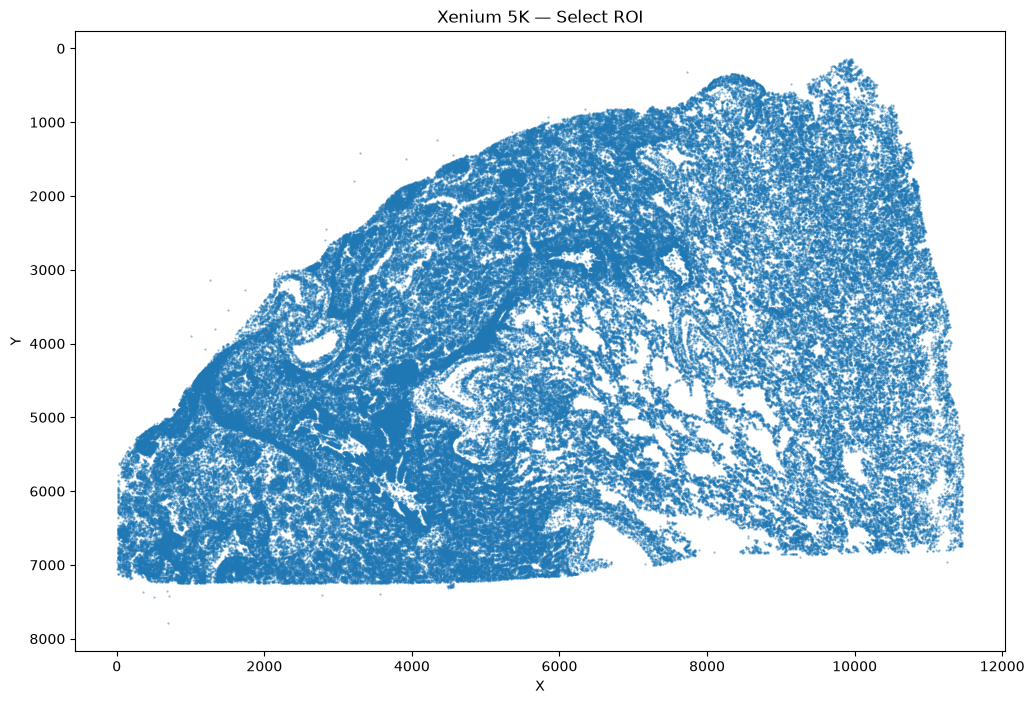

In [4]:
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(
    cells["x"],
    cells["y"],
    s=0.3,
    alpha=0.5,
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Xenium 5K — Select ROI")

plt.show()

Extract cells inside the ROI

In [5]:
ROI_X_MIN = 3000
ROI_X_MAX = 5000

ROI_Y_MIN = 3000
ROI_Y_MAX = 5000

In [6]:
roi_mask = (
    cells["x"].between(ROI_X_MIN, ROI_X_MAX)
    & cells["y"].between(ROI_Y_MIN, ROI_Y_MAX)
)

roi_cells = cells.loc[roi_mask].copy()

print("ROI cells:", len(roi_cells))
print(roi_cells.head())

ROI cells: 23474
         cell_id            x            y  group
8945  ahjljpnh-1  3041.321533  4253.839844      0
8946  ahjllada-1  3016.547607  4295.956055      4
8947  ahjlleeh-1  3092.912842  4270.034668      4
8948  ahjlmgjf-1  3097.069824  4258.206543      4
8949  ahjlmoag-1  3110.259521  3999.332275      0


Visualize the selected ROI

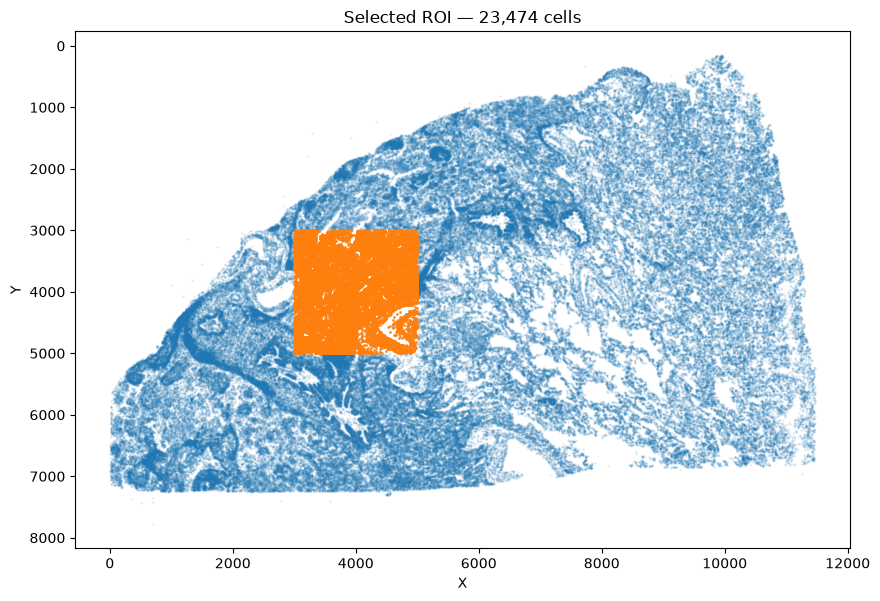

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(
    cells["x"],
    cells["y"],
    s=0.2,
    alpha=0.2,
)

ax.scatter(
    roi_cells["x"],
    roi_cells["y"],
    s=1,
    alpha=0.8,
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title(f"Selected ROI — {len(roi_cells):,} cells")

plt.show()

This lets you confirm that your ROI is in the expected tissue region.

## Load the boundary data

In [8]:
boundaries = pd.read_parquet(BOUNDARIES_FILE)

print("Boundaries:", boundaries.shape)
print(boundaries.head())
print(boundaries.index.name)

Boundaries: (266179, 1)
                                                      geometry
cell_id_str                                                   
aaaaadnb-1   b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x19\x00...
aaaabalp-1   b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x19\x00...
aaaadfei-1   b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x19\x00...
aaaadjia-1   b"\x01\x03\x00\x00\x00\x01\x00\x00\x00\x19\x00...
aaaafglb-1   b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x19\x00...
cell_id_str


### Match ROI cells to boundaries

The boundary file uses cell_id_str, while your coordinate table uses cell_id.

In [9]:
roi_boundary_ids = roi_cells["cell_id"].astype(str)

roi_boundaries = boundaries.loc[
    boundaries.index.isin(roi_boundary_ids)
].copy()

print("ROI boundaries:", roi_boundaries.shape)

ROI boundaries: (23474, 1)


In [10]:
print("ROI cells:", len(roi_cells))
print("ROI boundaries:", len(roi_boundaries))

ROI cells: 23474
ROI boundaries: 23474


## Convert WKB to Shapely polygons

In [11]:
geometries = from_wkb(
    roi_boundaries["geometry"].to_numpy()
)

print("Number of geometries:", len(geometries))
print("First geometry:", geometries[0])

Number of geometries: 23474
First geometry: POLYGON ((3041.72509765625 4249.36279296875, 3039.60009765625 4250.42529296875, 3038.962646484375 4251.0625, 3038.75 4251.0625, 3037.900146484375 4252.125, 3037.2626953125 4252.7626953125, 3036.625 4254.03759765625, 3036.625 4255.3125, 3037.2626953125 4256.58740234375, 3038.112548828125 4257.4375, 3038.962646484375 4257.86279296875, 3039.60009765625 4258.0751953125, 3040.875 4258.0751953125, 3041.5126953125 4257.86279296875, 3042.362548828125 4257.4375, 3043 4257.0126953125, 3044.275146484375 4255.73779296875, 3044.7001953125 4254.8876953125, 3045.337646484375 4254.25, 3045.97509765625 4252.97509765625, 3045.97509765625 4252.125, 3045.550048828125 4251.27490234375, 3044.91259765625 4250.6376953125, 3043.212646484375 4249.36279296875, 3041.72509765625 4249.36279296875))


## Convert polygons to napari coordinates

Shapely uses:

(X, Y)

Napari shapes use:

(Y, X)

So we explicitly switch the columns.

In [12]:
polygon_data = []

for geom in geometries:
    if geom.geom_type == "Polygon":
        coords = np.asarray(geom.exterior.coords)
        coords = coords[:, [1, 0]]  # X,Y → Y,X
        polygon_data.append(coords)

    elif geom.geom_type == "MultiPolygon":
        for polygon in geom.geoms:
            coords = np.asarray(polygon.exterior.coords)
            coords = coords[:, [1, 0]]
            polygon_data.append(coords)

print("Number of polygons:", len(polygon_data))

Number of polygons: 23474


## Start napari

In [13]:
import os

os.environ["QT_QPA_PLATFORM"] = "xcb"
os.environ["PYOPENGL_PLATFORM"] = "glx"

In [14]:
viewer = napari.Viewer()

## Add cell boundaries

In [15]:
viewer.add_shapes(
    polygon_data,
    shape_type="polygon",
    edge_width=0.5,
    face_color=[0, 0, 0, 0],
    edge_color="white",
    name="Cell boundaries",
)

<Shapes layer 'Cell boundaries' at 0x758ebbfbfdd0>

## Add cell center

In [16]:
roi_points = roi_cells[["y", "x"]].to_numpy()

viewer.add_points(
    roi_points,
    size=2,
    face_color="red",
    name="Cell centers",
)

<Points layer 'Cell centers' at 0x758e788e59d0>

## Add cluster labels as point colors

For an initial test, you can visualize the cluster assignments at the cell centers:

In [17]:
viewer.add_points(
    roi_cells[["y", "x"]].to_numpy(),
    size=3,
    face_color=roi_cells["group"].to_numpy(),
    name="Clusters",
)

/home/duydao/micromamba/envs/napari-env/lib/python3.11/site-packages/napari/layers/utils/color_transformations.py:41: UserWarning: The provided colors parameter contained illegal values, resetting all colors values to white.
  warnings.warn(


<Points layer 'Clusters' at 0x758e87f48b90>

However, this is not ideal for categorical cluster visualization, because group is categorical. We can make a proper categorical color mapping later.

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Get unique cluster IDs
cluster_ids = sorted(roi_cells["group"].dropna().unique())

# Create categorical colors
cmap = plt.get_cmap("tab20", len(cluster_ids))

# Map cluster ID → RGBA color
cluster_colors = {
    cluster_id: cmap(i)
    for i, cluster_id in enumerate(cluster_ids)
}

# Convert cluster IDs to RGBA colors
point_colors = np.array([
    cluster_colors[group]
    for group in roi_cells["group"]
])

# Add cluster-colored points
viewer.add_points(
    roi_cells[["y", "x"]].to_numpy(),
    size=3,
    face_color=point_colors,
    name="Clusters",
)

<Points layer 'Clusters [1]' at 0x758e87fbd9d0>

## Color the Cell boundaries

In [20]:
# Match boundary cluster labels
boundary_cluster_ids = roi_boundaries.index.astype(str)

# Create a lookup: cell_id -> cluster
cluster_lookup = roi_cells.set_index("cell_id")["group"]

# Get cluster for each boundary
boundary_groups = np.array([
    cluster_lookup.get(cell_id, np.nan)
    for cell_id in boundary_cluster_ids
])

# Unique clusters
cluster_ids = sorted(
    pd.Series(boundary_groups).dropna().unique()
)

# Create categorical colors
cmap = plt.get_cmap("tab20", len(cluster_ids))

cluster_colors = {
    cluster_id: cmap(i)
    for i, cluster_id in enumerate(cluster_ids)
}

# One edge color per polygon
edge_colors = np.array([
    cluster_colors[group]
    if not pd.isna(group)
    else (0.5, 0.5, 0.5, 1.0)
    for group in boundary_groups
])

# Add polygons with transparent interiors
viewer.add_shapes(
    polygon_data,
    shape_type="polygon",
    edge_width=0.8,
    edge_color=edge_colors,
    face_color=[0, 0, 0, 0],
    name="Cell boundaries — clusters",
)

<Shapes layer 'Cell boundaries — clusters' at 0x758e87e83a90>